<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation](#P3.1)
        - [3.1.1 Single-label VS Multi-label Classification](#P3.1.1)
        - [3.1.1 Similarity between restaurant categories](#P3.1.2)
        - [3.1.2 Empty Restaurant Reviews](#P3.1.3)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [1]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import plotly as px
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.dummy import DummyClassifier


# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from classification_prep import *
from modelling import *

c:\Users\filip\anaconda3\envs\TextMining3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [2]:
dataset_original = load_dataset('../data/02_atlanta_restaurant_slice_2023_translated.csv')

In [3]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,3349,33.779814,-84.410451,3,"One word amazing!! The red fish, halibut, frie...",en,en,False,"One word amazing!! The red fish, halibut, frie...","One word amazing!! The red fish, halibut, frie..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,False,3349,33.779814,-84.410451,1,First time here and the food is great and the ...,en,en,False,First time here and the food is great and the ...,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,False,3349,33.779814,-84.410451,14,I recently had the pleasure of dining at Optim...,en,en,False,I recently had the pleasure of dining at Optim...,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,False,3349,33.779814,-84.410451,9,Beautiful atmosphere and delicious food . All ...,en,en,False,Beautiful atmosphere and delicious food . All ...,Beautiful atmosphere and delicious food . All ...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,3349,33.779814,-84.410451,3,We had a wonderful dinner at the Optimist . Ou...,en,en,False,We had a wonderful dinner at the Optimist . Ou...,We had a wonderful dinner at the Optimist . Ou...


In [4]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53565 entries, 0 to 53564
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   title                           53565 non-null  object 
 1   categoryName                    53565 non-null  object 
 2   website                         50599 non-null  object 
 3   url                             53565 non-null  object 
 4   reviewsCount                    53565 non-null  int64  
 5   stars                           53565 non-null  float64
 6   text                            53565 non-null  object 
 7   is_chain                        53565 non-null  bool   
 8   total_reviews_by_title          53565 non-null  int64  
 9   latitude                        53565 non-null  float64
 10  longitude                       53565 non-null  float64
 11  num_sentences                   53565 non-null  int64  
 12  00_before_translating_cleaning  

| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [5]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation </font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

In [6]:
#Next cells are already done in the data prep notebook
dataset["categoryName"].value_counts().reset_index()

,categoryName,count
0,Mexican restaurant,8959
1,Fast food restaurant,5324
2,Italian restaurant,5108
3,American restaurant,5049
4,Pizza restaurant,4560
5,Breakfast restaurant,2491
6,Chinese restaurant,2484
7,Seafood restaurant,2048
8,Hamburger restaurant,1979
9,New American restaurant,1903


In [7]:
## Create dummy columns to assess msg_len and nr_sents
info = pd.DataFrame()
info["msg_len"] = dataset["text"].map(lambda content : len(str(content)))
info["sents"] = dataset["text"].map(lambda content :\
                                sent_tokenizer.tokenize(str(content)))
info["nr_sents"] = info["sents"].map(lambda content : len(content))

In [8]:
info.describe()
#is there reviews with 0 on len and 0 sentences?

,msg_len,nr_sents
count,53565.000000,53565.000000
mean,183.573789,3.246952
std,240.236352,3.085208
min,1.000000,1.000000
25%,46.000000,1.000000
50%,105.000000,2.000000
75%,228.000000,4.000000
max,4114.000000,45.000000


In [9]:
#this was already made on the data understanding notebook
#histogram_chart(info, "msg_len", "Length per review", "Message Length", bins = 100)

In [10]:
histogram_chart(info, "nr_sents", "Number of Sentences per review", "Number of Sentences")

In [11]:
# Extract the unique genres
unique_cuisine = []

for restaurants_cuisines in dataset["categoryName"]:
        if restaurants_cuisines not in unique_cuisine:
            unique_cuisine.append(restaurants_cuisines)

# Create a scratch dataset - "dataset_explore" - to plot the number of restaurants by category and to generate TF-IDF word clouds by label

dataset_explore = pd.DataFrame()
dataset_explore["text"] = dataset["text"]

for label in unique_cuisine:
    dataset_explore["has_label_{}".format(label)] = dataset["categoryName"].map(lambda labels_list : 1 if label in labels_list else 0)

<Axes: >

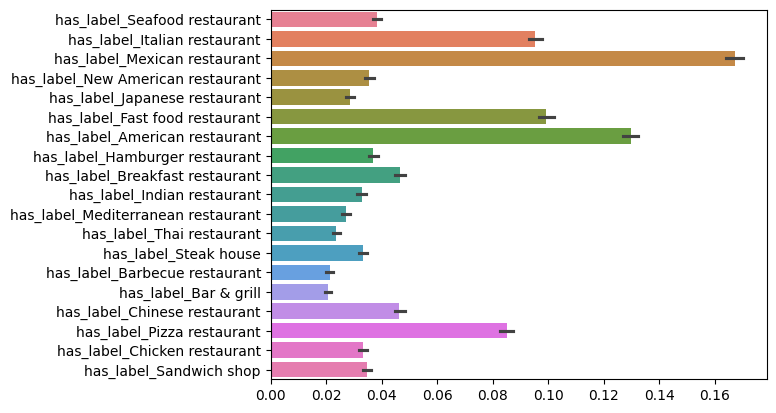

In [12]:
sns.barplot(dataset_explore, orient="h")

The restaurant category with the most comments is the "Italian Restaurant", and the one with the least is "Bar & Grill"

### <font color='#BFD72F' size=6>3.1.1 Similarity between restaurant categories</font> <a class="anchor" id="P3.1.1"></a>
  
[Back to TOC](#toc)

<font color='red'> !!!!!!!! ESTAMOS A IMPORTAR O DATASET TRANSLATED, PORTANTO EM VEZ DE USAR O TEXT, DEVE SE USAR O TEXT_FOR_PIPELINE

In [13]:
dataset['with_stopword_cleaned_review_body'] =\
    dataset['text_for_pipeline'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=False,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [14]:
category_reviews = dataset.groupby("categoryName")["with_stopword_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["with_stopword_cleaned_review_body"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

Analyizing first the similarity of the language used in the reviews between different categories before removing stop words.

In [15]:
heatmap_chart(similarity_df,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

As we can see, the great majority of categories have a very high similarity between them, indicating that the language used in reviews across different restaurant categories is quite similar. This is do to the fact that the reviews contain a lot of stopwords and common words that are not specefic to the restaurant category, they are common words used in everyday language. If the text data isnt treated the model might have difficulties in distinguishing between the different categories.

In [16]:
dataset['without_stopwords_cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

Now analyzing the similarity again after removing stopwords and other common words across all reviews.

In [17]:
category_reviews_cleaned1 = dataset.groupby("categoryName")["without_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix1 = vectorizer.fit_transform(category_reviews_cleaned1["without_stopwords_cleaned_review_body"])

similarity_matrix_cleaned1 = cosine_similarity(tfidf_matrix1)

similarity_df_cleaned1 = pd.DataFrame(
    similarity_matrix_cleaned1,
    index=category_reviews_cleaned1["categoryName"],
    columns=category_reviews_cleaned1["categoryName"])

heatmap_chart(similarity_df_cleaned1,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

As expected, after removing stopwords and common words in restaurant reviews, the similarity between categories decreases significantly. 
This indicates that the unique vocabulary associated with each restaurant category becomes more pronounced when generic terms are excluded, allowing for a clearer distinction in the language used across different types of restaurants. This is a great indicator that this treatment should be done before attempting the classification task.

After further analyzing the correlation matrix, three categories stand out as having higher similarity scores with each other: "New American restaurant", "American Restaurant", and "Steak house". This suggests that the language used in reviews for these categories shares more common terms and expressions compared to other categories. After further analyzing these Cousine Categories, it was concluded that they were very similar, therefore the three were joint into  one common categorie: "American & Steakhouse". For the rest of the exploration and calssification these categories will be seen as this new one created.

In [18]:
# joining the three categories into one : 'American & Steakhouse'
dataset['categoryName'] = dataset['categoryName'].replace({
    'American restaurant': 'American & Steakhouse',
    'New American restaurant': 'American & Steakhouse',
    'Steak house': 'American & Steakhouse',
})

In [19]:
category_reviews_cleaned2 = dataset.groupby("categoryName")["without_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix2 = vectorizer.fit_transform(category_reviews_cleaned2["without_stopwords_cleaned_review_body"])

similarity_matrix_cleaned2 = cosine_similarity(tfidf_matrix2)

similarity_df_cleaned2 = pd.DataFrame(
    similarity_matrix_cleaned2,
    index=category_reviews_cleaned2["categoryName"],
    columns=category_reviews_cleaned2["categoryName"])

heatmap_chart(similarity_df_cleaned2,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

### <font color='#BFD72F' size=6>3.1.3 Empty Restaurant Reviews</font> <a class="anchor" id="P3.1.3"></a>
  
[Back to TOC](#toc)

In [20]:
# Count the number of exactly empty reviews
empty_exact = (dataset["with_stopword_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces = dataset["with_stopword_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples = dataset[dataset["with_stopword_cleaned_review_body"].str.strip() == ""]["with_stopword_cleaned_review_body"].head(10)
print("Exactly empty reviews:", empty_exact)
print("Reviews with only spaces (or tabs):", empty_spaces)
print("\nExamples of empty reviews:")
print(examples)

Exactly empty reviews: 0
Reviews with only spaces (or tabs): 0

Examples of empty reviews:
Series([], Name: with_stopword_cleaned_review_body, dtype: object)


In [21]:
# Count the number of exactly empty reviews
empty_exact1 = (dataset["without_stopwords_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces1 = dataset["without_stopwords_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples1 = dataset[dataset["without_stopwords_cleaned_review_body"].str.strip() == ""]["without_stopwords_cleaned_review_body"].head(10)

print("Exactly empty reviews:", empty_exact1)
print("Reviews with only spaces (or tabs):", empty_spaces1)
print("\nExamples of empty reviews:")
print(examples1)

Exactly empty reviews: 12
Reviews with only spaces (or tabs): 12

Examples of empty reviews:
12254    
13730    
14009    
25856    
28726    
29359    
32203    
36174    
37181    
40580    
Name: without_stopwords_cleaned_review_body, dtype: object


In [22]:
empty_idx = dataset[dataset["with_stopword_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
dataset.loc[empty_idx, :]

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline,with_stopword_cleaned_review_body,without_stopwords_cleaned_review_body


In [23]:
empty_idx1 = dataset[dataset["without_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
dataset.loc[empty_idx1, :]

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline,with_stopword_cleaned_review_body,without_stopwords_cleaned_review_body
12254,Marlow's Tavern,American & Steakhouse,http://www.marlowstavern.com/locations/dunwoody,https://www.google.com/maps/place/Marlow's+Tav...,668,3.0,The,True,1799,33.950040,-84.334998,1,The,en,en,False,The,The,the,
13730,Buon Fornello Café & Bottega,Italian restaurant,http://www.buonfornello.com/,https://www.google.com/maps/place/Buon+Fornell...,332,5.0,A++++,False,332,33.919896,-84.352272,1,A++++,hu,en,True,A++++,A++++,a,
14009,Baraonda Ristorante & Bar,Italian restaurant,http://www.baraondaatlanta.com/,https://www.google.com/maps/place/Baraonda+Ris...,955,2.0,Just,False,955,33.920937,-84.378772,1,Just,et,en,True,Just,Just,just,
25856,Taco mexico,Mexican restaurant,http://taco-mexico.com/,https://www.google.com/maps/place/Taco+mexico/...,310,1.0,We,False,310,34.195679,-84.135397,1,We,de,en,True,We,We,we,
28726,Hardee’s,Fast food restaurant,https://locations.hardees.com/ga/cumming/125-w...,https://www.google.com/maps/place/Hardee%E2%80...,907,3.0,Not what they were,False,907,34.206418,-84.141298,1,Not what they were,en,en,False,Not what they were,Not what they were,not what they were,
29359,Wendy's,Fast food restaurant,https://locations.wendys.com/united-states/ga/...,https://www.google.com/maps/place/Wendy's/@34....,628,1.0,Just no,True,3838,34.186582,-84.140130,1,Just no,en,en,False,Just no,Just no,just no,
32203,Jimmy John's,Sandwich shop,https://locations.jimmyjohns.com/ga/peachtreec...,https://www.google.com/maps/place/Jimmy+John's...,233,5.0,A+++,True,409,33.396506,-84.602057,1,A+++,hu,en,True,A+++,A+++,a,
36174,Ranchero Bar & Grill (Westpark),Mexican restaurant,http://www.elrancheropeachtreecity.com/?fbclid...,https://www.google.com/maps/place/Ranchero+Bar...,750,2.0,Not for me.,False,750,33.398291,-84.590100,1,Not for me.,no,en,True,Not for me.,Not for me.,not for me,
37181,PITA Mediterranean Street Food,Mediterranean restaurant,NaN,https://www.google.com/maps/place/PITA+Mediter...,420,5.0,A++,False,420,33.378224,-84.560324,1,A++,hu,en,True,A++,A++,a,
40580,Panda Express,Chinese restaurant,https://www.pandaexpress.com/locations/ga/peac...,https://www.google.com/maps/place/Panda+Expres...,472,3.0,It's,True,925,33.397193,-84.598307,1,It is,en,en,False,It is,It is,it is,


In [24]:
(dataset["without_stopwords_cleaned_review_body"].str.strip() == "").sum()

12

In [25]:
dataset.drop(empty_idx1, inplace=True)
print((dataset["without_stopwords_cleaned_review_body"].str.strip() == "").sum())

0


### <font color='#BFD72F' size=6>3.1.5 Most frequent words by category</font> <a class="anchor" id="P3.1.3"></a>
  
[Back to TOC](#toc)

In [26]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['without_stopwords_cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['without_stopwords_cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,food,1190
1,Seafood restaurant,great,818
2,Seafood restaurant,good,711
3,Seafood restaurant,service,667
4,Seafood restaurant,place,360
5,Seafood restaurant,back,350
6,Seafood restaurant,seafood,350
7,Seafood restaurant,shrimp,338
8,Seafood restaurant,time,321
9,Seafood restaurant,delicious,251


In [27]:
treemap_chart(df_freq,
              path_col = [px.Constant('Atlanta Restaurants Categories'), 'category', 'word'],
              value_col='count',
              title = 'Most frequent words per cuisine category in Atlanta restaurant reviews')

Looking at this graph, it is evident that some more general words are still present in the top 15 words per category, such as "like", "great". These words may not provide significant discriminatory power for classification tasks, as they are commonly used across various contexts. It might be beneficial to further refine the stopword list or apply additional filtering techniques to remove such generic terms, thereby enhancing the focus on more category-specific vocabulary.

### <font color='#BFD72F' size=6>3.1.4 Categories By Reviews Dataset</font> <a class="anchor" id="P3.1.3"></a>
  
[Back to TOC](#toc)

In [28]:
new_dataset = (
    dataset.groupby("without_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   # remove duplicates + sort so order is fixed
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)


display(new_dataset)
new_dataset.info()

,without_stopwords_cleaned_review_body,categories
0,!!service ambience great food good raw chicken...,[American & Steakhouse]
1,0 stars give one reviewterrible whole establis...,[Fast food restaurant]
2,0 stars option thats deserve pretty sloppy ser...,[Sandwich shop]
3,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
4,0 stars would appropriate called asked speak m...,[American & Steakhouse]
...,...,...
49792,zero stars thing id put horrible staff includi...,[Breakfast restaurant]
49793,zero zero zero stars horrible horrible experie...,[American & Steakhouse]
49794,zing salad loved,[Chicken restaurant]
49795,zucchini fries banging great place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49797 entries, 0 to 49796
Data columns (total 2 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   without_stopwords_cleaned_review_body  49797 non-null  object
 1   categories                             49797 non-null  object
dtypes: object(2)
memory usage: 778.2+ KB


In [29]:
# Count categories per comment
category_counts = new_dataset['categories'].apply(len)

# Count how many comments have 1, 2, 3, ...
count_by_n = category_counts.value_counts().sort_index()

# Create dataframe
df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

# Keep only rows where the number of categories > 1
df_plot_filtered = df_plot[df_plot["num_categories"] > 1]



In [30]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


There are 2 comments with all 17 categories assigned to them:

In [31]:
new_dataset[new_dataset['categories'].apply(len) == 17]

,without_stopwords_cleaned_review_body,categories
20393,good,"[American & Steakhouse, Bar & grill, Barbecue ..."
20776,good food,"[American & Steakhouse, Bar & grill, Barbecue ..."
23498,great food,"[American & Steakhouse, Bar & grill, Barbecue ..."
24010,great food great service,"[American & Steakhouse, Bar & grill, Barbecue ..."


In [32]:
new_dataset['categories'].apply(tuple).unique()

array([('American & Steakhouse',), ('Fast food restaurant',),
       ('Sandwich shop',), ('Chinese restaurant',),
       ('Mediterranean restaurant',), ('Pizza restaurant',),
       ('Bar & grill',), ('Mexican restaurant',), ('Italian restaurant',),
       ('Barbecue restaurant',), ('Chicken restaurant',),
       ('Breakfast restaurant',), ('Hamburger restaurant',),
       ('Seafood restaurant',), ('Indian restaurant',),
       ('Japanese restaurant',), ('Thai restaurant',),
       ('Mexican restaurant', 'Sandwich shop'),
       ('Barbecue restaurant', 'Breakfast restaurant'),
       ('Mexican restaurant', 'Pizza restaurant'),
       ('American & Steakhouse', 'Breakfast restaurant', 'Hamburger restaurant', 'Indian restaurant', 'Italian restaurant', 'Mexican restaurant', 'Sandwich shop', 'Seafood restaurant'),
       ('American & Steakhouse', 'Italian restaurant', 'Mexican restaurant'),
       ('Chinese restaurant', 'Pizza restaurant'),
       ('Fast food restaurant', 'Mexican restauran

In [33]:
new_dataset['categories'].apply(tuple).nunique()

360

In [34]:
# see what categories co-occur the most (appear together in the same review)
new_dataset["categories_tuple"] = new_dataset["categories"].apply(lambda x: tuple(sorted(x)))

from itertools import combinations

# lista de todas as categorias únicas
all_cats = sorted({cat for cats in new_dataset["categories"] for cat in cats})

# matriz vazia
co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []

# preencher
for cats in new_dataset["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix",)



[('American & Steakhouse', 'Mexican restaurant', 125), ('Fast food restaurant', 'Mexican restaurant', 111), ('American & Steakhouse', 'Italian restaurant', 103), ('Italian restaurant', 'Mexican restaurant', 97), ('American & Steakhouse', 'Fast food restaurant', 87), ('Breakfast restaurant', 'Mexican restaurant', 82), ('Chinese restaurant', 'Mexican restaurant', 79), ('American & Steakhouse', 'Breakfast restaurant', 78), ('Mexican restaurant', 'Pizza restaurant', 74), ('Italian restaurant', 'Pizza restaurant', 71), ('Fast food restaurant', 'Pizza restaurant', 69), ('Mexican restaurant', 'Seafood restaurant', 69), ('Breakfast restaurant', 'Fast food restaurant', 68), ('American & Steakhouse', 'Pizza restaurant', 67), ('Chicken restaurant', 'Mexican restaurant', 67), ('American & Steakhouse', 'Seafood restaurant', 66), ('Chicken restaurant', 'Fast food restaurant', 66), ('Fast food restaurant', 'Italian restaurant', 65), ('American & Steakhouse', 'Chinese restaurant', 62), ('Chinese resta

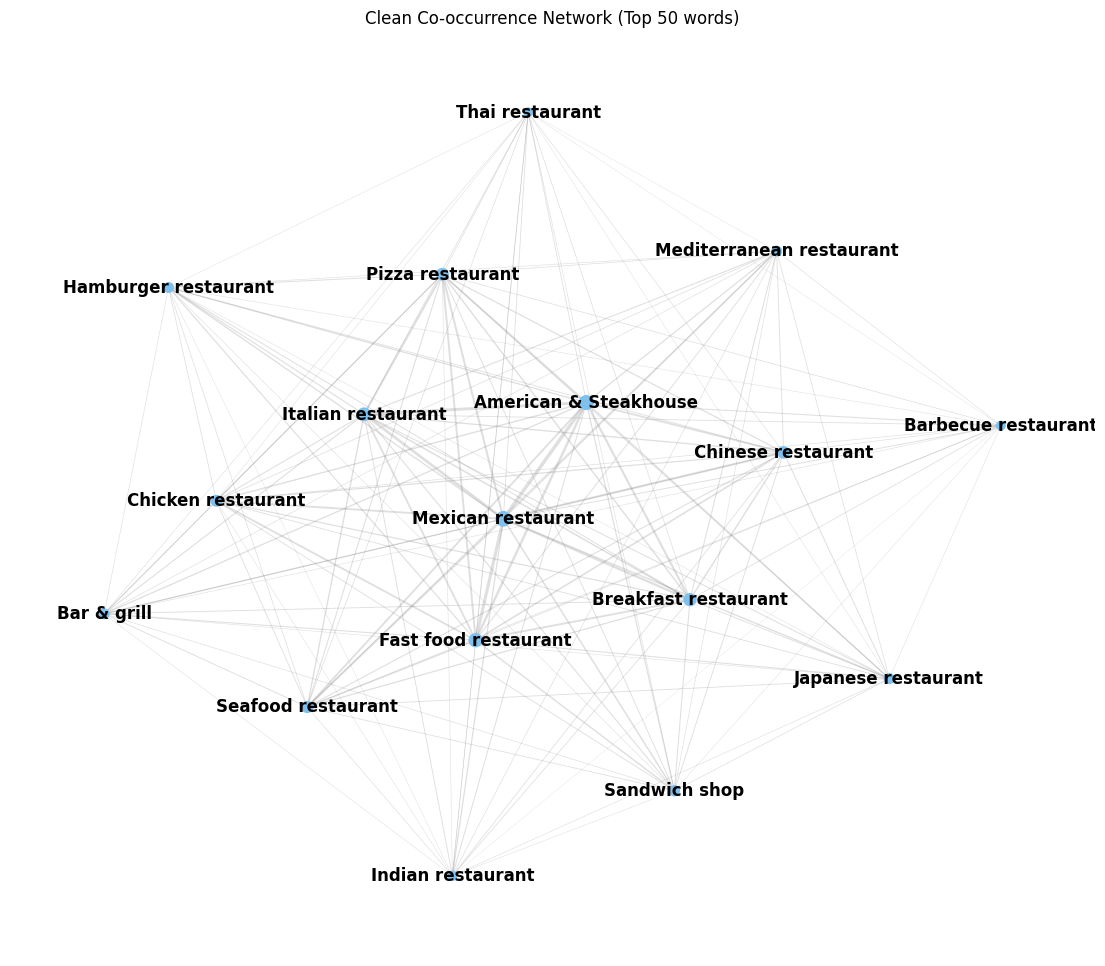

In [35]:
cooc_dict = {}

for cats in new_dataset['categories']:
    # cria todos os pares possíveis (sem repetir) dentro da review
    for cat1, cat2 in combinations(sorted(cats), 2):
        cooc_dict[(cat1, cat2)] = cooc_dict.get((cat1, cat2), 0) + 1

# pega todas as categorias únicas
all_categories = sorted(set([cat for sublist in new_dataset['categories'] for cat in sublist]))

# cria matriz vazia
cooc_matrix = pd.DataFrame(0, index=all_categories, columns=all_categories)

# preenche a matriz
for (cat1, cat2), count in cooc_dict.items():
    cooc_matrix.loc[cat1, cat2] = count
    cooc_matrix.loc[cat2, cat1] = count  # matriz simétrica

plot_cooccurrence_network(cooc_matrix, top_n=50, min_weight=10)


In [36]:
mlb = MultiLabelBinarizer()
binarised_categories = mlb.fit_transform(new_dataset["categories"])

In [37]:
new_dataset


,without_stopwords_cleaned_review_body,categories,categories_tuple
0,!!service ambience great food good raw chicken...,[American & Steakhouse],"(American & Steakhouse,)"
1,0 stars give one reviewterrible whole establis...,[Fast food restaurant],"(Fast food restaurant,)"
2,0 stars option thats deserve pretty sloppy ser...,[Sandwich shop],"(Sandwich shop,)"
3,0 stars rat droppings floor last back booth ro...,[Chinese restaurant],"(Chinese restaurant,)"
4,0 stars would appropriate called asked speak m...,[American & Steakhouse],"(American & Steakhouse,)"
...,...,...,...
49792,zero stars thing id put horrible staff includi...,[Breakfast restaurant],"(Breakfast restaurant,)"
49793,zero zero zero stars horrible horrible experie...,[American & Steakhouse],"(American & Steakhouse,)"
49794,zing salad loved,[Chicken restaurant],"(Chicken restaurant,)"
49795,zucchini fries banging great place,[Pizza restaurant],"(Pizza restaurant,)"


In [38]:
'''cleaned_category_texts = {}

for category in dataset["categoryName"].unique():
    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()
    combined_text = " ".join(cat_texts)

    cleaned_text = main_pipeline(
        combined_text,
        print_output=False,
        no_stopwords=True,  # keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food","great","good","service","place",
                         "experience","delicious","staff","back","best"],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )

    cleaned_category_texts[category] = cleaned_text
'''

'cleaned_category_texts = {}\n\nfor category in dataset["categoryName"].unique():\n    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()\n    combined_text = " ".join(cat_texts)\n\n    cleaned_text = main_pipeline(\n        combined_text,\n        print_output=False,\n        no_stopwords=True,  # keep stopwords\n        stopwords_tokeep=[],\n        extra_stopwords=["food","great","good","service","place",\n                         "experience","delicious","staff","back","best"],\n        convert_diacritics=True,\n        lowercase=True,\n        lemmatized=True,\n        list_pos=[],\n        stemmed=False,\n        pos_tags_list=\'no_pos\',\n        tokenized_output=False,\n        no_emojis=True,\n        no_hashtags=True,\n        hashtag_retain_words=False,\n        no_newlines=True,\n        no_urls=True,\n        no_punctuation=True,\n        treat_repeated_chars=True\n    )\n\n    cleaned_category_texts[category] = cleaned_text\n'

In [39]:
'''df_low = dataset[dataset["stars"].isin([1, 2, 3])]
df_high = dataset[dataset["stars"].isin([4, 5])]


low_text = main_pipeline(
    " ".join(df_low["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
high_text = main_pipeline(
    " ".join(df_high["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
'''

'df_low = dataset[dataset["stars"].isin([1, 2, 3])]\ndf_high = dataset[dataset["stars"].isin([4, 5])]\n\n\nlow_text = main_pipeline(\n    " ".join(df_low["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\n    convert_diacritics=True,\n    lowercase=True,\n    lemmatized=True,\n    list_pos=[],\n    stemmed=False,\n    pos_tags_list=\'no_pos\',\n    tokenized_output=False,\n    no_emojis=True,\n    no_hashtags=True,\n    hashtag_retain_words=False,\n    no_newlines=True,\n    no_urls=True,\n    no_punctuation=True,\n    treat_repeated_chars=True\n)\nhigh_text = main_pipeline(\n    " ".join(df_high["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\

In [40]:
'''
low_counts = Counter(low_text.split())
high_counts = Counter(high_text.split())

word_category_map = {}

all_words = set(low_counts.keys()) | set(high_counts.keys())

for word in all_words:
    if low_counts.get(word, 0) > high_counts.get(word, 0):
        word_category_map[word] = "negative"
    elif high_counts.get(word, 0) > low_counts.get(word, 0):
        word_category_map[word] = "positive"
    else:
        word_category_map[word] = "neutral"'''



'\nlow_counts = Counter(low_text.split())\nhigh_counts = Counter(high_text.split())\n\nword_category_map = {}\n\nall_words = set(low_counts.keys()) | set(high_counts.keys())\n\nfor word in all_words:\n    if low_counts.get(word, 0) > high_counts.get(word, 0):\n        word_category_map[word] = "negative"\n    elif high_counts.get(word, 0) > low_counts.get(word, 0):\n        word_category_map[word] = "positive"\n    else:\n        word_category_map[word] = "neutral"'

In [41]:
'''def color_by_category(word, *args, **kwargs):
    category = word_category_map.get(word, "neutral")

    if category == "negative":
        return "rgb(220, 20, 60)"   # red
    elif category == "positive":
        return "rgb(34, 139, 34)"   # green
    else:
        return "rgb(120, 120, 120)" # gray'''



'def color_by_category(word, *args, **kwargs):\n    category = word_category_map.get(word, "neutral")\n\n    if category == "negative":\n        return "rgb(220, 20, 60)"   # red\n    elif category == "positive":\n        return "rgb(34, 139, 34)"   # green\n    else:\n        return "rgb(120, 120, 120)" # gray'

In [42]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

folder_path = "../images/visualizations/wordclouds"

for category, text in cleaned_category_texts.items():

    # TF-IDF
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()

    freq_dict = dict(zip(words, vector))

    # WordCloud
    wc = WordCloud(
        width=1600,
        height=800,
        background_color="white",
        color_func=color_by_category
    ).generate_from_frequencies(freq_dict)

    wc.to_file(f"{folder_path}/wordcloud_{category.replace(' ', '_')}.png")'''



'from sklearn.feature_extraction.text import TfidfVectorizer\nfrom wordcloud import WordCloud\n\nfolder_path = "../images/visualizations/wordclouds"\n\nfor category, text in cleaned_category_texts.items():\n\n    # TF-IDF\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n\n    freq_dict = dict(zip(words, vector))\n\n    # WordCloud\n    wc = WordCloud(\n        width=1600,\n        height=800,\n        background_color="white",\n        color_func=color_by_category\n    ).generate_from_frequencies(freq_dict)\n\n    wc.to_file(f"{folder_path}/wordcloud_{category.replace(\' \', \'_\')}.png")'

In [43]:
'''# Folder to save WordCloud images
folder_path = '../images/visualizations/wordclouds'

# Generating a WordCloud for each category
for category, text in cleaned_category_texts.items():
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()
    
    tfidf_df = pd.DataFrame([vector], columns=words)
    
    wordcloud_from_vectorized(
        folder_path=folder_path,
        filename=f"wordcloud_{category.replace(' ', '_')}.png",
        vectorized_df=tfidf_df,
        top_n=100  
    )'''



'# Folder to save WordCloud images\nfolder_path = \'../images/visualizations/wordclouds\'\n\n# Generating a WordCloud for each category\nfor category, text in cleaned_category_texts.items():\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n    \n    tfidf_df = pd.DataFrame([vector], columns=words)\n    \n    wordcloud_from_vectorized(\n        folder_path=folder_path,\n        filename=f"wordcloud_{category.replace(\' \', \'_\')}.png",\n        vectorized_df=tfidf_df,\n        top_n=100  \n    )'

Looking at this graph, it is evident that some more general words are still present in the top 15 words per category, such as "like", "great". These words may not provide significant discriminatory power for classification tasks, as they are commonly used across various contexts. It might be beneficial to further refine the stopword list or apply additional filtering techniques to remove such generic terms, thereby enhancing the focus on more category-specific vocabulary.

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

WITH HERMETIC CLASSIFIER IMPLEMENTATION

In [44]:
X = new_dataset["without_stopwords_cleaned_review_body"]
y = binarised_categories
y


array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [45]:
preprocessor = MainPipeline()

In [46]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")

In [47]:
base_classifier = LinearSVC(max_iter=3000)

In [48]:
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
prec_micro = []
prec_macro = []
rec_micro = []
rec_macro = []
f1_micro = []
f1_macro = []


for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    modelhermetic = HermeticClassifier(
        preprocessor=preprocessor,
        vectorizer=tfidf_vectorizer,
        classifier=OneVsRestClassifier(base_classifier)
    )

    modelhermetic.fit(X_train, y_train)

    # ---- TRAIN predictions ----
    y_train_pred = modelhermetic.predict(X_train)
    print("---- Train metrics ----")
    fold_score_calculator(y_train_pred, y_train, verbose=True)

    # ---- VALIDATION predictions ----
    y_pred = modelhermetic.predict(X_test)
    print("---- Validation metrics ----")
    fold_score_calculator(y_pred, y_test, verbose=True)





===== Fold 1 =====
Accuracy: 0.3990909090909091 
Precision: 0.8131314472201941 
Recall: 0.398988425250462 
F1: 0.531106696188494

===== Fold 2 =====
Accuracy: 0.3899087170227706 
Precision: 0.805627403936903 
Recall: 0.39338199513381994 
F1: 0.5241501401312039

===== Fold 3 =====
Accuracy: 0.39034911717495985 
Precision: 0.8024295129396477 
Recall: 0.39355592329407185 
F1: 0.5232627535131307

===== Fold 4 =====
Accuracy: 0.3998395024576186 
Precision: 0.8033095540168486 
Recall: 0.40116788321167884 
F1: 0.5291521591753471

===== Fold 5 =====
Accuracy: 0.3955560004003603 
Precision: 0.8082138215688548 
Recall: 0.39803272302298404 
F1: 0.5293953114065122


In [50]:
print(metrics.classification_report(y_test, y_pred, target_names=mlb.classes_))

                          precision    recall  f1-score   support

   American & Steakhouse       0.70      0.37      0.48      1684
             Bar & grill       0.70      0.18      0.29       215
     Barbecue restaurant       0.81      0.45      0.58       222
    Breakfast restaurant       0.72      0.25      0.38       475
      Chicken restaurant       0.80      0.27      0.40       339
      Chinese restaurant       0.88      0.37      0.52       476
    Fast food restaurant       0.74      0.42      0.53      1011
    Hamburger restaurant       0.75      0.36      0.49       386
       Indian restaurant       0.93      0.52      0.67       343
      Italian restaurant       0.84      0.36      0.51       991
     Japanese restaurant       0.93      0.40      0.56       297
Mediterranean restaurant       0.94      0.37      0.53       282
      Mexican restaurant       0.87      0.48      0.62      1685
        Pizza restaurant       0.84      0.52      0.64       864
         

c:\Users\filip\anaconda3\envs\TextMining3\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.



In [ ]:
bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bigram_bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")

In [ ]:
hermetic_classifier = HermeticClassifier(preprocessor, bigram_tfidf_vectorizer, base_classifier)

In [ ]:
#ml_class_ovr = OneVsRestClassifier(LogisticRegression()) # wont work with classifier base estimator, only classifier estimator

from sklearn.multioutput import ClassifierChain


ml_class_cc = ClassifierChain(LogisticRegression())

parameter_grid = {'preprocessor__no_stopwords':[True, False],
                  'preprocessor__lemmatized':[True],
                  'preprocessor__lowercase':[True],   
                  'preprocessor__custom_stopwords':[["food", "service"], []],               
                  'vectorizer':[bigram_tfidf_vectorizer,bigram_bow_vectorizer],
                  'classifier__alpha':[0.1, 0.5],
                  'd2v_vector_size':[300], 
                  'd2v_window':[20]}

In [ ]:
scores = ["accuracy","precision_weighted","recall_weighted","f1_weighted"]

grid_search = GridSearchCV(
    estimator=hermetic_classifier,
    param_grid=parameter_grid,
    scoring=scores,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=4,
    refit="f1_weighted" 
)
grid_result = grid_search.fit(X, y)


NameError: name 'hermetic_classifier' is not defined

In [ ]:
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

Best params: {'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__penalty': 'l2', 'classifier__estimator__random_state': 1, 'classifier__estimator__solver': 'lbfgs', 'd2v_vector_size': 300, 'd2v_window': 20, 'preprocessor__custom_stopwords': ['food', 'great', 'good', 'service', 'place', 'experience', 'delicious', 'staff', 'back', 'best'], 'preprocessor__lemmatized': True, 'preprocessor__lowercase': True, 'preprocessor__no_stopwords': True, 'vectorizer': TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')}
Best score: 0.4843955022694117


WITHOUT HERMITIC CLASSIFIER - BELOW CODE IS JUST FOR REFERENCE

In [ ]:
X_tfidf = tfidf_vectorizer.fit_transform(new_dataset["without_stopwords_cleaned_review_body"])
X_bow = bow_vectorizer.fit_transform(new_dataset["without_stopwords_cleaned_review_body"])

In [ ]:
from sklearn.neural_network import MLPClassifier
from skmultilearn.adapt import MLkNN
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multioutput import ClassifierChain
from sklearn.svm import SVC


# ==========================================================
# Testing Models
# ==========================================================

models = {
    #"OvR_LogReg": OneVsRestClassifier(LogisticRegression(max_iter=3000)),
    #"ClassifierChain_LogReg": ClassifierChain(LogisticRegression(max_iter=3000)),
    #"MLP": OneVsRestClassifier(MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=800)),
    "OvR_LinSVC": OneVsRestClassifier(LinearSVC(max_iter=3000)),
    #"OvR_LinearSVC_Calibrated": OneVsRestClassifier(CalibratedClassifierCV(LinearSVC(max_iter=3000), cv=3)),
    #"Dummy_ClassifierChain": ClassifierChain(DummyClassifier()),
    #"Dummy_OvR": OneVsRestClassifier(DummyClassifier()),
    #"OvR_RandomForest": OneVsRestClassifier(RandomForestClassifier(
            #n_estimators=300,
            #max_depth=None,
            #min_samples_leaf=2,
            #max_features="sqrt",
            #class_weight="balanced_subsample",
            #n_jobs=-1,
            #random_state=42
        #)
    #)
}

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []           
detailed_reports = []   
fold_general_metrics = []

for model_name, model in models.items():
    print(f"\n==================== {model_name} ====================\n")

    macro_f1_list = []
    micro_f1_list = []
    weighted_f1_list = []
    macro_precision_list = []
    macro_recall_list = []

    for fold, (train_idx, test_idx) in enumerate(mskf.split(X_tfidf, y), start=1):

        print(f"---- Fold {fold} of 5 ----")

        X_train = X_bow[train_idx]
        X_test = X_bow[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # ==========================================================
        # Geral METRICS
        # ==========================================================

        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        micro_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

  
        macro_f1_list.append(macro_f1)
        micro_f1_list.append(micro_f1)
        weighted_f1_list.append(weighted_f1)

        macro_precision_list.append(macro_precision)
        macro_recall_list.append(macro_recall)


        fold_general_metrics.append({
            "Model": model_name,
            "Fold": fold,
            "F1 Macro": macro_f1,
            "Precision Macro": macro_precision,
            "Recall Macro": macro_recall,
            "F1 Micro": micro_f1,
            "F1 Weighted": weighted_f1
        })

        # ==========================================================
        # METRICS BY CATEGORY (classification_report)
        # ==========================================================

        report = classification_report(
            y_test,
            y_pred,
            target_names=mlb.classes_,
            output_dict=True,
            zero_division=0
        )

        detailed_reports.append({
            "model": model_name,
            "fold": fold,
            "report": report
        })

    # ==============================================================
    # AVERAGE METRICS BY MODEL (for final ranking)
    # ==============================================================

    results.append({
        "Model": model_name,
        "F1 Macro": np.mean(macro_f1_list),
        "Precision Macro": np.mean(macro_precision_list),
        "Recall Macro": np.mean(macro_recall_list),
        "F1 Micro": np.mean(micro_f1_list),
        "F1 Weighted": np.mean(weighted_f1_list),
    })

# ==============================================================
# FINAL TABLE: GENERAL METRICS BY MODEL
# ==============================================================

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="F1 Macro", ascending=False).reset_index(drop=True)

print("\n\n==================== RANKING FINAL ====================\n")
print(results_df_sorted)

# Melhor modelo
best = results_df_sorted.iloc[0]
print(f"\nMELHOR MODELO: {best['Model']}")

# ==============================================================
# TABLE: METRICS BY CATEGORY IN EACH FOLD
# ==============================================================

rows = []

for entry in detailed_reports:
    model = entry["model"]
    fold = entry["fold"]
    report = entry["report"]

    for label in mlb.classes_:
        rows.append({
            "Model": model,
            "Fold": fold,
            "Category": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1": report[label]["f1-score"],
            "Support": report[label]["support"],
        })

category_metrics_df = pd.DataFrame(rows)
best_model_category_metrics = category_metrics_df[
    category_metrics_df["Model"] == best["Model"]
]

# ==============================================================
# FINAL TABLE: AVERAGE BY CATEGORY (5 FOLDS)
# ==============================================================

mean_category_metrics_best = (
    best_model_category_metrics
    .groupby("Category")
    .agg({
        "Precision": "mean",
        "Recall": "mean",
        "F1": "mean",
        "Support": "sum"
    })
    .reset_index()
)
print(mean_category_metrics_best)


==================== OvR_LinSVC ====================

---- Fold 1 of 5 ----
---- Fold 2 of 5 ----
---- Fold 3 of 5 ----
---- Fold 4 of 5 ----
---- Fold 5 of 5 ----


==================== RANKING FINAL ====================

        Model  F1 Macro  Precision Macro  Recall Macro  F1 Micro  F1 Weighted
0  OvR_LinSVC  0.496892          0.63244      0.411365  0.520195     0.517642

MELHOR MODELO: OvR_LinSVC
                    Category  Precision    Recall        F1  Support
0      American & Steakhouse   0.597554  0.408103  0.484852   8417.0
1                Bar & grill   0.387934  0.200387  0.263842   1073.0
2        Barbecue restaurant   0.705044  0.477013  0.567537   1111.0
3       Breakfast restaurant   0.533139  0.296040  0.380529   2378.0
4         Chicken restaurant   0.524682  0.313340  0.392058   1698.0
5         Chinese restaurant   0.613440  0.362908  0.455777   2378.0
6       Fast food restaurant   0.619396  0.435580  0.511332   5053.0
7       Hamburger restaurant   0.598514  

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)